__In this notebook, we will benchmark three feature selection algorithms against the exhaustive search:__
1. Forward Selection
2. Backward Selection
3. Greedier Forward Selection

First, we will retrieve the logged results and store it as a pandas DataFrame.



In [44]:
import pandas as pd
from itertools import combinations

DATASETS = ['aav', 'gb1', 'gfp', 'location', 'meltome', 'stability']
EMBEDDINGS = ['B', 'C', 'D', 'E', 'F', 'G']

# We will store the dataframes in a dictionary.
dfs = {}

for dataset in DATASETS:
    # Right now, the logs for the single embeddings and combined embeddings are separated so we will combine them.
    single_embedding_log = pd.read_csv(f"results/tplm_benchmark_results/{dataset}_log.tsv", sep='\t')
    single_embedding_log = single_embedding_log[single_embedding_log["Embedding"].isin(EMBEDDINGS)]
    
    combined_embedding_log = pd.read_csv(f"results/embedding_fusion_results/{dataset}_log.tsv", sep='\t')
    dfs[dataset] = pd.concat([single_embedding_log, combined_embedding_log])

    # The logs are for individual seeds, so we will compute mean and standard deviation.
    dfs[dataset] = dfs[dataset].groupby(["Dataset", "Embedding"], as_index=False).agg({
        "Best Val Metric": ["mean", "std"],
        "Test Metric": ["mean", "std"],
        "Run Time": ["sum"]
    })
    
    # Flatten column names
    dfs[dataset].columns = ["_".join(col).strip("_") for col in dfs[dataset].columns]
    
    # Rename columns for clarity
    dfs[dataset].rename(columns={
        "Best Val Metric_mean": "Average Val",
        "Best Val Metric_std": "Std Val",
        "Test Metric_mean": "Average Test",
        "Test Metric_std": "Std Test",
        "Run Time_sum": "Run Time"
    }, inplace=True)

Now, we will define functions for each of the three feature selection algorithms and their helper functions.

In [46]:
# Common utilities for feature selection algorithms
def print_initial_message(dataset, algorithm_name):
    print(f"Starting {algorithm_name} for dataset: {dataset}\n")

def get_validation_accuracy(data, feature_set):
    """Get validation accuracy for a feature set."""
    if isinstance(feature_set, list):
        feature_set = ''.join(sorted(feature_set))
    
    candidate_acc = data.loc[data["Embedding"] == feature_set, "Average Val"].values
    return candidate_acc[0] if len(candidate_acc) > 0 else None

def get_test_accuracy(data, feature_set):
    """Get test accuracy for a feature set."""
    if isinstance(feature_set, list):
        feature_set = ''.join(sorted(feature_set))
    
    candidate_acc = data.loc[data["Embedding"] == feature_set, "Average Test"].values
    return candidate_acc[0] if len(candidate_acc) > 0 else None

def evaluate_and_print_subset(data, feature_set, metric_name="Validation Accuracy"):
    """Evaluate a feature set and print results."""
    if isinstance(feature_set, list):
        feature_set = ''.join(sorted(feature_set))
   
    row = data.loc[data["Embedding"] == feature_set]
    accuracy = row["Average Val"].values[0] if not row.empty else None
    runtime = row["Run Time"].values[0] if not row.empty and "Run Time" in row else 0
    
    if accuracy is not None:
        print(f"Evaluating subset {feature_set}: {metric_name} = {accuracy:.4f}, Runtime = {runtime:.4f}")
    
    return accuracy, runtime

def print_final_results(data, dataset, selected_features, best_val_acc, best_test_acc_selected):
    """Print final results of feature selection."""
    # Get final selected subset metrics
    if isinstance(selected_features, list):
        selected_key = ''.join(sorted(selected_features))
    else:
        selected_key = selected_features
    
    selected_row = data.loc[data["Embedding"] == selected_key]
    selected_std_val = selected_row["Std Val"].values[0] if not selected_row.empty else 0
    selected_std_test = selected_row["Std Test"].values[0] if not selected_row.empty else 0
    
    # Find the true best combination based on the highest test metric
    best_test_row = data.loc[data["Average Test"].idxmax()]
    best_test_subset = best_test_row["Embedding"]
    best_test_val = best_test_row["Average Val"]
    best_test_std_val = best_test_row["Std Val"]
    best_test_acc = best_test_row["Average Test"]
    best_test_std_acc = best_test_row["Std Test"]
    
    print(f"Final Selected Subset for {dataset}: {selected_key}, "
          f"Final Validation Accuracy: {best_val_acc:.4f} ± {selected_std_val:.4f}, "
          f"Final Test Accuracy: {best_test_acc_selected:.4f} ± {selected_std_test:.4f}\n")
          
    print(f"True Best Subset (Highest Test Accuracy): {best_test_subset}, "
          f"Validation Accuracy: {best_test_val:.4f} ± {best_test_std_val:.4f}, "
          f"Test Accuracy: {best_test_acc:.4f} ± {best_test_std_acc:.4f}\n")
          
    relative_performance = best_test_acc_selected / best_test_acc
    print(f"Relative Performance: {relative_performance:.2f}")
    
    return selected_std_test, best_test_subset, best_test_acc, best_test_std_acc


In [47]:
def exhaustive_search(dataset):
    """
    Performs exhaustive search by evaluating all possible feature combinations.
    """
    data = dfs[dataset]
    total_runtime = 0
    best_val_acc = 0
    best_features = []
    print_initial_message(dataset, "Exhaustive Search")
    
    # Iterate through all possible subset sizes
    for subset_size in range(1, len(EMBEDDINGS) + 1):
        for candidate_subset in combinations(EMBEDDINGS, subset_size):
            # Sort the subset to ensure consistent naming
            sorted_subset = ''.join(sorted(candidate_subset))
            
            # Evaluate the current subset
            candidate_acc, runtime = evaluate_and_print_subset(data, sorted_subset, "Validation Accuracy")
            total_runtime += runtime
            
            # Update best features if current subset is better
            if candidate_acc is not None and candidate_acc > best_val_acc:
                best_val_acc = candidate_acc
                best_features = list(candidate_subset)
    
    # If no valid subset found
    if not best_features:
        print("No valid feature combinations found. Stopping search.\n")
        return best_features, 0
    
    # Get test accuracy for the best subset
    best_test_acc_selected = get_test_accuracy(data, best_features)
    
    # Print final results
    selected_std_test, best_test_subset, best_test_acc, best_test_std_acc = print_final_results(
        data, dataset, best_features, best_val_acc, best_test_acc_selected
    )
    
    return best_features, best_test_acc_selected, selected_std_test, best_test_subset, best_test_acc, best_test_std_acc, total_runtime

In [48]:
def forward_selection(dataset):
    """
    Performs forward selection by incrementally adding features that improve performance.
    """
    data = dfs[dataset]
    selected_features = []
    best_val_acc = 0
    total_runtime = 0
    print_initial_message(dataset, "Forward Selection")
    
    # Step 1: Find the best single embedding
    best_candidate = None
    for feature in EMBEDDINGS:
        candidate_acc, runtime = evaluate_and_print_subset(data, feature, "Validation Accuracy")
        total_runtime += runtime
        if candidate_acc is not None and candidate_acc > best_val_acc:
            best_val_acc = candidate_acc
            best_candidate = feature
    
    if best_candidate:
        selected_features = [best_candidate]
        print(f"Selected {best_candidate}, Best Accuracy: {best_val_acc:.4f}\n")
    else:
        print("No valid single embeddings found. Stopping selection.\n")
        return selected_features, best_val_acc
    
    # Step 2+: Iterate through larger subsets including the best found subset
    best_test_acc_selected = get_test_accuracy(data, selected_features)
    for subset_size in range(2, len(EMBEDDINGS) + 1):
        best_new_candidate = None
        for candidate_subset in combinations(EMBEDDINGS, subset_size):
            # Ensure previous best is included
            if all(feat in candidate_subset for feat in selected_features):
                sorted_subset = ''.join(sorted(candidate_subset))
                candidate_acc, runtime = evaluate_and_print_subset(data, sorted_subset)
                total_runtime += runtime
                if candidate_acc is not None and candidate_acc > best_val_acc:
                    best_val_acc = candidate_acc
                    best_new_candidate = candidate_subset
                    best_test_acc_selected = get_test_accuracy(data, sorted_subset)
        
        if best_new_candidate:
            selected_features = list(best_new_candidate)
            print(f"Selected {''.join(sorted(best_new_candidate))}, Best Accuracy: {best_val_acc:.4f}\n")
        else:
            break  # Stop if no improvement
    
    selected_std_test, best_test_subset, best_test_acc, best_test_std_acc = print_final_results(data, dataset, selected_features, best_val_acc, best_test_acc_selected)
    return selected_features, best_test_acc_selected, selected_std_test, best_test_subset, best_test_acc, best_test_std_acc, total_runtime

In [49]:
def greedier_forward_selection(dataset):
    """
    Performs a greedier forward selection by ranking features first, then adding them in order.
    """
    data = dfs[dataset]
    total_runtime = 0
    print_initial_message(dataset, "Greedier Forward Selection")
    
    # Step 1: Evaluate and rank single embeddings by validation performance
    embedding_performance = {}
    for feature in EMBEDDINGS:
        candidate_acc, runtime = evaluate_and_print_subset(data, feature)
        total_runtime += runtime
        if candidate_acc is not None:
            embedding_performance[feature] = candidate_acc
    
    if not embedding_performance:
        print("No valid embeddings found. Stopping selection.\n")
        return None, None
    
    # Rank embeddings by validation performance
    sorted_embeddings = sorted(embedding_performance, key=embedding_performance.get, reverse=True)
    previous_best = sorted_embeddings[0]
    best_val_acc = embedding_performance[previous_best]
    print(f"Starting with best single embedding: {previous_best}, Validation Accuracy: {best_val_acc:.4f}\n")
    
    best_test_acc_selected = get_test_accuracy(data, previous_best)
    
    # Step 2: Iteratively add the next best embedding and check improvement
    for i in range(1, len(sorted_embeddings)):
        new_combination = ''.join(sorted(previous_best + sorted_embeddings[i]))
        candidate_acc, runtime = evaluate_and_print_subset(data, new_combination)
        total_runtime += runtime
        
        if candidate_acc is not None and candidate_acc > best_val_acc:
            best_val_acc = candidate_acc
            previous_best = new_combination
            best_test_acc_selected = get_test_accuracy(data, new_combination)
            print(f"New best combination: {previous_best}, Validation Accuracy: {best_val_acc:.4f}\n")
    
    selected_std_test, best_test_subset, best_test_acc, best_test_std_acc = print_final_results(data, dataset, previous_best, best_val_acc, best_test_acc_selected)
    return previous_best, best_test_acc_selected, selected_std_test, best_test_subset, best_test_acc, best_test_std_acc, total_runtime

In [51]:
def reverse_elimination(dataset):
    """
    Performs reverse elimination by starting with all features and removing those that don't hurt performance.
    """
    data = dfs[dataset]
    total_runtime = 0
    print_initial_message(dataset, "Reverse Elimination")
    
    # Step 1: Start with all embeddings as the initial best set
    current_best = ''.join(sorted(EMBEDDINGS))
    best_val_acc, runtime = evaluate_and_print_subset(data, current_best)
    total_runtime += runtime
    
    if best_val_acc is None:
        print("No valid embeddings found. Stopping selection.\n")
        return None, None
    
    best_test_acc_selected = get_test_accuracy(data, current_best)
    print(f"Starting with full set: {current_best}, Validation Accuracy: {best_val_acc:.4f}\n")
    
    # Step 2: Iteratively remove the least important embedding
    for i in range(len(EMBEDDINGS) - 1):
        worst_candidate = None
        worst_val_acc = best_val_acc
        for feature in current_best:
            new_combination = ''.join(sorted(set(current_best) - {feature}))
            candidate_acc, runtime = evaluate_and_print_subset(data, new_combination)
            total_runtime += runtime
            
            if candidate_acc is not None and candidate_acc >= worst_val_acc:
                worst_val_acc = candidate_acc
                worst_candidate = feature
                best_test_acc_selected = get_test_accuracy(data, new_combination)
        
        if worst_candidate:
            current_best = ''.join(sorted(set(current_best) - {worst_candidate}))
            best_val_acc = worst_val_acc
            print(f"Removed {worst_candidate}, New Best Combination: {current_best}, Validation Accuracy: {best_val_acc:.4f}\n")
        else:
            break  # Stop if no improvement
    
    selected_std_test, best_test_subset, best_test_acc, best_test_std_acc = print_final_results(data, dataset, current_best, best_val_acc, best_test_acc_selected)
    return current_best, best_test_acc_selected, selected_std_test, best_test_subset, best_test_acc, best_test_std_acc, total_runtime

Now, we will run the three selection algorithms for each of the datasets and save their results into a DataFrame.


In [52]:
def process_algorithm(dataset, algorithm_name, algorithm_func):
    result = algorithm_func(dataset)
    return [dataset, algorithm_name, *result]

# Run algorithms and collect results
results = []
for dataset in DATASETS:
    results.extend([
        process_algorithm(dataset, 'exhaustive search', exhaustive_search),
        process_algorithm(dataset, 'forward selection', forward_selection),
        process_algorithm(dataset, 'greedier forward selection', greedier_forward_selection),
        process_algorithm(dataset, 'reverse elimination', reverse_elimination)
    ])

# Define DataFrame columns
columns = ['dataset', 'algorithm', 'identified_subset', 'average_metric', 'std_dev',
           'true_best_subset', 'true_best_avg_metric', 'true_best_std_dev', 'relative_performance', 'total_runtime (s)']

# Process results into DataFrame rows
df_rows = []
for dataset, algorithm, identified_subset, avg_metric, std_dev, true_best_subset, true_best_avg_metric, true_best_std_dev, total_runtime in results:
    # Ensure identified_subset is formatted consistently
    if isinstance(identified_subset, list):
        identified_subset = ''.join(sorted(identified_subset))

    relative_performance = avg_metric / true_best_avg_metric
    df_rows.append([dataset, algorithm, identified_subset, avg_metric, std_dev,
                    true_best_subset, true_best_avg_metric, true_best_std_dev, relative_performance, round(total_runtime)])

# Create DataFrame
df = pd.DataFrame(df_rows, columns=columns)


Starting Exhaustive Search for dataset: aav

Evaluating subset B: Validation Accuracy = 0.8371, Runtime = 170.1920
Evaluating subset C: Validation Accuracy = 0.8603, Runtime = 155.2084
Evaluating subset D: Validation Accuracy = 0.8015, Runtime = 133.8110
Evaluating subset E: Validation Accuracy = 0.8292, Runtime = 139.5176
Evaluating subset F: Validation Accuracy = 0.8205, Runtime = 149.7549
Evaluating subset G: Validation Accuracy = 0.8376, Runtime = 151.5434
Evaluating subset BC: Validation Accuracy = 0.8608, Runtime = 248.7686
Evaluating subset BD: Validation Accuracy = 0.8434, Runtime = 198.3509
Evaluating subset BE: Validation Accuracy = 0.8478, Runtime = 216.2828
Evaluating subset BF: Validation Accuracy = 0.8502, Runtime = 238.8237
Evaluating subset BG: Validation Accuracy = 0.8539, Runtime = 237.3541
Evaluating subset CD: Validation Accuracy = 0.8650, Runtime = 184.9550
Evaluating subset CE: Validation Accuracy = 0.8645, Runtime = 193.8191
Evaluating subset CF: Validation Accur

In [53]:
df

,dataset,algorithm,identified_subset,average_metric,std_dev,true_best_subset,true_best_avg_metric,true_best_std_dev,relative_performance,total_runtime (s)
0,aav,exhaustive search,CDEFG,0.668491,0.024082,BCDE,0.731567,0.006323,0.913779,16471
1,aav,forward selection,CDEFG,0.668491,0.024082,BCDE,0.731567,0.006323,0.913779,5010
2,aav,greedier forward selection,BCDEFG,0.696848,0.015177,BCDE,0.731567,0.006323,0.952541,2554
3,aav,reverse elimination,CDEFG,0.668491,0.024082,BCDE,0.731567,0.006323,0.913779,4100
4,gb1,exhaustive search,BFG,0.832500,0.011872,BCDEFG,0.849443,0.007757,0.980055,4490
5,gb1,forward selection,BFG,0.832500,0.011872,BCDEFG,0.849443,0.007757,0.980055,1231
6,gb1,greedier forward selection,BDEFG,0.837480,0.008272,BCDEFG,0.849443,0.007757,0.985918,732
7,gb1,reverse elimination,BFG,0.832500,0.011872,BCDEFG,0.849443,0.007757,0.980055,1511
8,gfp,exhaustive search,CF,0.670960,0.000758,CF,0.670960,0.000758,1.000000,19114
9,gfp,forward selection,CF,0.670960,0.000758,CF,0.670960,0.000758,1.000000,3761


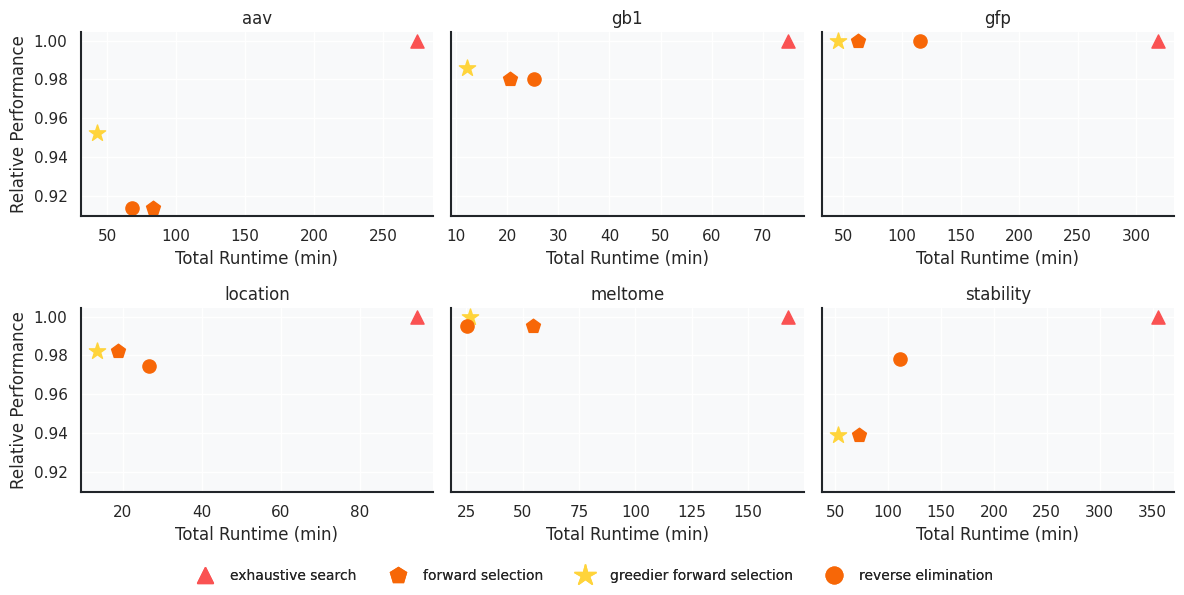

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")
# Set relative performance to 1 for exhaustive search
df.loc[df['algorithm'] == 'exhaustive search', 'relative_performance'] = 1.0

# Abbreviation mapping
abbr_map = {
    'exhaustive search': 'ES',
    'forward selection': 'FS',
    'greedier forward selection': 'GFS',
    'reverse elimination': 'RE',
}
df['algorithm_abbr'] = df['algorithm'].map(abbr_map).fillna(df['algorithm'])

# Marker mapping
marker_map = {
    'ES': '^',
    'FS': 'p',
    'GFS': '*',
    'RE': 'o',
}
color_map = {
    'ES': '#FA5252',
    'FS': '#F76707',
    'GFS': '#FFD43B',
    'RE': '#F76707',
}

# Convert runtime to minutes
df['total_runtime_min'] = df['total_runtime (s)'] / 60

datasets = df['dataset'].unique()
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6), sharey=True)
axes = axes.flatten()

for i, dataset in enumerate(datasets):

    ax = axes[i]

    # Set facecolor
    ax.set_facecolor("#F8F9FA")

    # Spine styling
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_color('#212529')
    ax.spines['left'].set_linewidth(1.5)

    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('#212529')
    ax.spines['bottom'].set_linewidth(1.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    subset = df[df['dataset'] == dataset]

    for abbr in subset['algorithm_abbr'].unique():
        sub = subset[subset['algorithm_abbr'] == abbr]
        marker = marker_map.get(abbr)
        size = 90
        if marker == '*':
            size = 150
        elif marker == 'p':
            size = 110

        color = color_map.get(abbr, 'gray')
        ax.scatter(sub['total_runtime_min'], sub['relative_performance'],
                   label=abbr, marker=marker, color=color, s=size)

    ax.set_title(dataset)
    ax.set_xlabel("Total Runtime (min)")
    ax.grid(True)
    ax.set_facecolor("#F8F9FA")

axes[0].set_ylabel("Relative Performance")
axes[3].set_ylabel("Relative Performance")

import matplotlib.lines as mlines

# Reverse mapping: abbreviation → full name
full_name_map = {v: k for k, v in abbr_map.items()}

legend_elements = [
    mlines.Line2D([], [], color=color_map[abbr], marker=marker_map[abbr],
                  linestyle='None',
                  markersize=12 if marker_map[abbr] != '*' else 16,
                  label=full_name_map[abbr])
    for abbr in abbr_map.values()
]

fig.legend(handles=legend_elements, loc='lower center', ncol=len(abbr_map),
           frameon=False, fontsize=10)


fig.legend(handles=legend_elements, loc='lower center', ncol=len(abbr_map),
           frameon=False, fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # Leave space for legend
plt.show()
#plt.savefig("runtime.svg")

In [42]:
avg_relative_performance = df.groupby('algorithm').agg({
    'relative_performance': ['mean'],
    'total_runtime (s)': ['mean']
})

avg_relative_performance
avg_relative_performance.columns = ['_'.join(col).strip() for col in avg_relative_performance.columns.values]
avg_relative_performance = avg_relative_performance.reset_index()


In [43]:
avg_relative_performance

,algorithm,relative_performance_mean,total_runtime (s)_mean
0,exhaustive search,1.000000,12849.166667
1,forward selection,0.998301,3176.333333
2,greedier forward selection,0.994543,1875.666667
3,reverse elimination,0.992574,3947.000000
